In [58]:
from sklearn.datasets import make_classification
import numpy as np
x,y = make_classification(n_samples=100, n_features=2 , n_informative=1 , n_redundant=0 , n_classes=2 , n_clusters_per_class =1 , random_state=42 , hypercube=False , class_sep=20)

In [59]:
import matplotlib.pyplot as plt

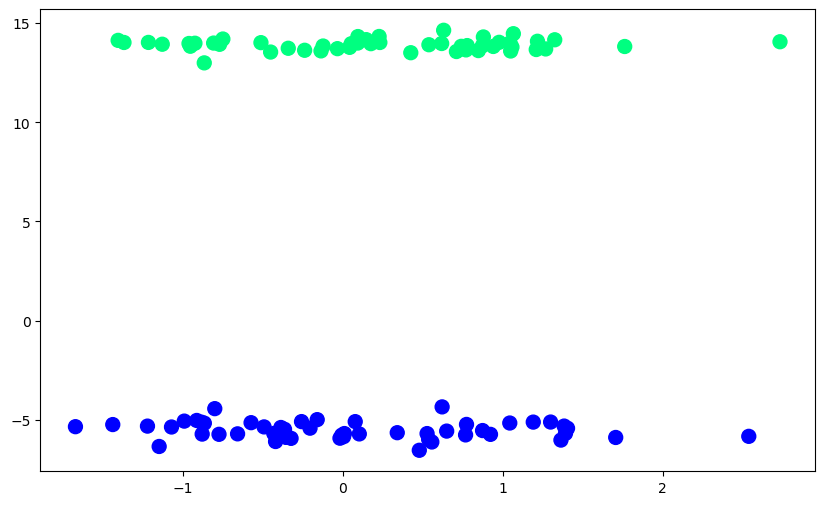

In [60]:
plt.figure(figsize=(10,6))
plt.scatter(x[: , 0], x[:,1], c=y , cmap="winter", s=100)

In [61]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(penalty=None, solver="lbfgs")  
lr.fit(x, y)


LogisticRegression(penalty=None)

In [62]:
print(lr.coef_)

[[0.01678265 1.9605295 ]]


In [63]:
print(lr.intercept_)

[-0.18746573]


In [64]:
m1=-(lr.coef_[0][0]/lr.coef_[0][1])
b1=-(lr.intercept_/lr.coef_[0][1])

In [65]:
x_input=np.linspace(-3,3,100)
y_input=m1*x_input + b1

In [66]:
def gd(x,y ):
    x= np.insert(x,0,1,axis=1)
    weights = np.ones(x.shape[1])
    lr= 0.5
    for i in range(2500):
        y_hat= sigmoid(np.dot(x, weights))
        weights= weights + lr*(np.dot((y-y_hat),x)/x.shape[0])
    return weights[1:] , weights[0]

In [67]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [68]:
coef_, intercept_ = gd(x,y)

In [69]:
m=-(coef_[0]/coef_[1])
b=-(intercept_/coef_[1])

In [70]:
m

-0.4193504011241622

In [71]:
x_input1= np.linspace(-3,3,100 )
y_input1= m*x_input + b

(-3.0, 2.0)

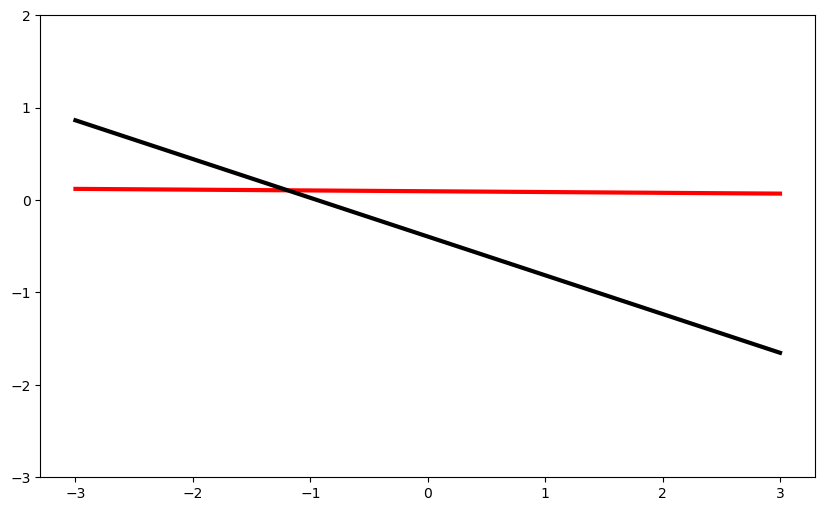

In [72]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color="red", linewidth = 3)
plt.plot(x_input1 , y_input1 , color="black", linewidth=3)
plt.scatter(x[: , 0], x[: , 1], c=y,cmap="winter", s=100)
plt.ylim(-3,2)
